# Subject Area Prediction — Deep Learning (MLP)
### Multi-label Text Classification using TensorFlow/Keras
---

## Step 1 — Install Dependencies

In [1]:
!pip install tensorflow pandas numpy scikit-learn matplotlib

Defaulting to user installation because normal site-packages is not writeable


## Step 2 — Import Libraries

In [2]:
import pandas as pd
import numpy as np
import pickle
import os
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.layers import TextVectorization
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MultiLabelBinarizer

os.makedirs('models', exist_ok=True)
print(f'TensorFlow version: {tf.__version__}')
print('Libraries loaded!')

TensorFlow version: 2.21.0
Libraries loaded!


In [4]:
import os
os.chdir(r"C:\Users\karatmal narendar\Desktop\MLP\research_paper_project")
print(os.getcwd())

C:\Users\karatmal narendar\Desktop\MLP\research_paper_project


## Step 3 — Load Dataset

In [5]:
arxiv_data = pd.read_csv('arxiv_data_210930-054931.csv')
print(f'Dataset shape: {arxiv_data.shape}')
print(f'Columns: {arxiv_data.columns.tolist()}')
arxiv_data.head()

Dataset shape: (56181, 3)
Columns: ['terms', 'titles', 'abstracts']


,terms,titles,abstracts
0,['cs.LG'],Multi-Level Attention Pooling for Graph Neural...,Graph neural networks (GNNs) have been widely ...
1,"['cs.LG', 'cs.AI']",Decision Forests vs. Deep Networks: Conceptual...,Deep networks and decision forests (such as ra...
2,"['cs.LG', 'cs.CR', 'stat.ML']",Power up! Robust Graph Convolutional Network v...,Graph convolutional networks (GCNs) are powerf...
3,"['cs.LG', 'cs.CR']",Releasing Graph Neural Networks with Different...,With the increasing popularity of Graph Neural...
4,['cs.LG'],Recurrence-Aware Long-Term Cognitive Network f...,Machine learning solutions for pattern classif...


## Step 4 — Clean Dataset

In [6]:
arxiv_data = arxiv_data.drop_duplicates()
arxiv_data = arxiv_data.dropna(subset=['abstracts', 'terms'])
arxiv_data = arxiv_data.reset_index(drop=True)

# Use first 10000 rows
arxiv_data = arxiv_data[:10000]

print(f'Clean dataset shape: {arxiv_data.shape}')
arxiv_data.head(3)

Clean dataset shape: (10000, 3)


,terms,titles,abstracts
0,['cs.LG'],Multi-Level Attention Pooling for Graph Neural...,Graph neural networks (GNNs) have been widely ...
1,"['cs.LG', 'cs.AI']",Decision Forests vs. Deep Networks: Conceptual...,Deep networks and decision forests (such as ra...
2,"['cs.LG', 'cs.CR', 'stat.ML']",Power up! Robust Graph Convolutional Network v...,Graph convolutional networks (GCNs) are powerf...


## Step 5 — Prepare Labels

In [7]:
# The terms column contains subject areas like "['cs.LG', 'cs.AI']"
# Convert string to list
import ast

arxiv_data['terms'] = arxiv_data['terms'].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)

# Multi-label binarize
mlb = MultiLabelBinarizer()
y = mlb.fit_transform(arxiv_data['terms'])
vocab = mlb.classes_

print(f'Number of unique subject areas: {len(vocab)}')
print(f'Label matrix shape: {y.shape}')
print(f'Sample classes: {vocab[:10]}')

# Save vocabulary
with open('models/vocab.pkl', 'wb') as f:
    pickle.dump(vocab, f)
print('Vocabulary saved!')

Number of unique subject areas: 448
Label matrix shape: (10000, 448)
Sample classes: ['00-02' '00Bxx' '05C99, 62M45'
 '10010147.10010257.10010258.10010259.10010263' '11Z05' '14J60'
 '14J60 (Primary) 14F05, 14J26 (Secondary)' '15A06' '2010'
 '2020: 49N45, 93B30, 93E12, 93B15, 49N10, 90C40, 60J10, 62M05']
Vocabulary saved!


## Step 6 — Train/Test Split

In [8]:
X = arxiv_data['abstracts'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Train size: {len(X_train)}')
print(f'Test size:  {len(X_test)}')

Train size: 8000
Test size:  2000


## Step 7 — Text Vectorization

In [9]:
MAX_TOKENS = 20000

text_vectorizer = TextVectorization(
    max_tokens=MAX_TOKENS,
    output_mode='multi_hot',
    ngrams=2
)

# Adapt on training data only
text_vectorizer.adapt(X_train)
print(f'Vocabulary size: {len(text_vectorizer.get_vocabulary())}')

# Save vectorizer
config = text_vectorizer.get_config()
with open('models/text_vectorizer_config.pkl', 'wb') as f:
    pickle.dump(config, f)

weights = text_vectorizer.get_weights()
with open('models/text_vectorizer_weights.pkl', 'wb') as f:
    pickle.dump(weights, f)

print('Text vectorizer saved!')

Vocabulary size: 20000
Text vectorizer saved!


## Step 8 — Build MLP Model

In [10]:
def build_model(num_classes):
    inputs = keras.Input(shape=(MAX_TOKENS,), name='text_input')
    x = layers.Dense(512, activation='relu')(inputs)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(128, activation='relu')(x)
    outputs = layers.Dense(num_classes, activation='sigmoid', name='outputs')(x)
    model = keras.Model(inputs, outputs)
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

num_classes = y.shape[1]
model = build_model(num_classes)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ text_input (InputLayer)              │ (None, 20000)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 512)                 │      10,240,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 256)                 │         131,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ outputs (Dense)                      │ (None, 448)                 │          57,792 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 10,462,528 (39.91 MB)

 Trainable params: 10,462,528 (39.91 MB)

 Non-trainable params: 0 (0.00 B)

## Step 9 — Prepare TF Datasets

In [11]:
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

def make_dataset(texts, labels, batch_size=BATCH_SIZE, is_train=True):
    dataset = tf.data.Dataset.from_tensor_slices((texts, labels))
    if is_train:
        dataset = dataset.shuffle(len(texts))
    dataset = dataset.batch(batch_size)
    dataset = dataset.map(
        lambda x, y: (text_vectorizer(x), y),
        num_parallel_calls=AUTOTUNE
    )
    return dataset.prefetch(AUTOTUNE)

train_dataset = make_dataset(X_train, y_train, is_train=True)
test_dataset  = make_dataset(X_test,  y_test,  is_train=False)
print('Datasets ready!')

Datasets ready!


## Step 10 — Train the Model

In [12]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=3, restore_best_weights=True
    )
]

history = model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=20,
    callbacks=callbacks
)

Epoch 1/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 17s 59ms/step - accuracy: 0.4534 - loss: 0.0382 - val_accuracy: 0.5575 - val_loss: 0.0105
Epoch 2/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 14s 57ms/step - accuracy: 0.5870 - loss: 0.0091 - val_accuracy: 0.5590 - val_loss: 0.0100
Epoch 3/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 14s 57ms/step - accuracy: 0.6031 - loss: 0.0069 - val_accuracy: 0.5490 - val_loss: 0.0102
Epoch 4/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 14s 57ms/step - accuracy: 0.5860 - loss: 0.0050 - val_accuracy: 0.5430 - val_loss: 0.0116
Epoch 5/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 21s 58ms/step - accuracy: 0.5774 - loss: 0.0035 - val_accuracy: 0.5310 - val_loss: 0.0133


## Step 11 — Check Accuracy

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.5590 - loss: 0.0100
Test Loss:     0.0100
Test Accuracy: 55.90%


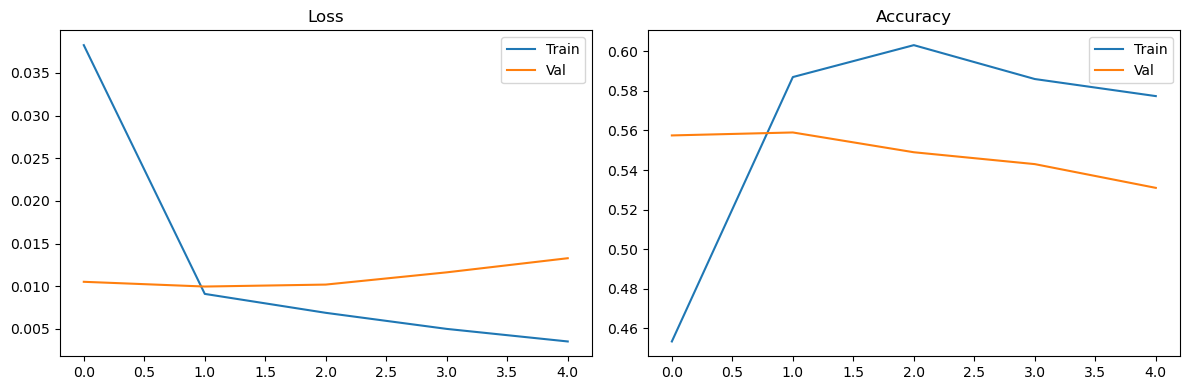

In [13]:
loss, accuracy = model.evaluate(test_dataset)
print(f'Test Loss:     {loss:.4f}')
print(f'Test Accuracy: {accuracy*100:.2f}%')

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history['loss'], label='Train')
axes[0].plot(history.history['val_loss'], label='Val')
axes[0].set_title('Loss')
axes[0].legend()
axes[1].plot(history.history['accuracy'], label='Train')
axes[1].plot(history.history['val_accuracy'], label='Val')
axes[1].set_title('Accuracy')
axes[1].legend()
plt.tight_layout()
plt.show()

## Step 12 — Test Prediction

In [14]:
def invert_multi_hot(encoded_labels, vocab):
    hot_indices = np.argwhere(encoded_labels == 1.0)[..., 0]
    return np.take(vocab, hot_indices)

def predict_category(abstract, model, vectorizer, vocab):
    preprocessed = vectorizer([abstract])
    preds = model.predict(preprocessed)
    return invert_multi_hot(np.round(preds).astype(int)[0], vocab)

# Test
sample = 'We present a transformer-based model for machine translation using self-attention mechanisms achieving state-of-the-art results.'
predicted = predict_category(sample, model, text_vectorizer, vocab)
print(f'Predicted subject areas: {predicted}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
Predicted subject areas: ['cs.LG']


## Step 13 — Save Model

In [15]:
model.save('models/model.h5')
print('Model saved to models/model.h5')
print('All files in models folder:')
for f in os.listdir('models'):
    print(f'  - {f}')
print('\nNow run: streamlit run app.py')

Model saved to models/model.h5
All files in models folder:
  - embeddings.pkl
  - model.h5
  - rec_model.pkl
  - sentences.pkl
  - text_vectorizer_config.pkl
  - text_vectorizer_weights.pkl
  - vocab.pkl

Now run: streamlit run app.py
